## Laboratorio 6

- Diego Valenzuela 22309 
- Daniel Dubon 22233
- Nelson García Bravatti 22434
- Joaquin Puente 22296

# Task 1

1. El entorno de simulación que usarán es LunarLanderContinuous-v2 de Gymnasium, que tiene un
espacio de acción continuo de dos dimensiones representando la fuerza de dos propulsores.
Argumenten formalmente por qué Q-Learning tabular y DQN son inapropiados para este entorno. Su
argumento debe mencionar explícitamente el espacio de acción, el operador argmax, y la
representación de la política

Tanto Q-Learning tabular como DQN son algoritmos diseñados para entornos discretos por lo que su aplicación en LunarLanderContinuous-v2 es inapropiada ya que el entorno posee un espacio de acción continuo bidimensional para controlar las fuerzas de los dos propulsores. Q-Learning tabular requiere construir una tabla o matriz donde cada par de estado y acción tiene una entrada unica, como el espacio de acción es continuo existen infinitas acciones posibles y crear esta tabla es imposible sin aplicar una discretización extrema que causaria la maldición de la dimensionalidad y perdida de información. Para el caso de DQN el obstaculo principal es el operador argmax donde DQN usa redes neuronales y puede manejar estados continuos pero su ecuación de actualización de Bellman requiere aplicar el argmax sobre todas las acciones posibles para encontrar el mayor valor esperado. Evaluar el $\arg\max_a Q(s, a)$ en un espacio de acción continuo requiere resolver un problema de optimización complejo en cada iteración del agente lo cual hace que el algoritmo sea computacionalmente inviable.Finalmente esto se reduce a la representación de la politica. Los algoritmos basados en valor como Q-Learning y DQN tienen una representación de politica implicita que depende totalmente de evaluar acciones discretas individuales para elegir la mejor. En dominios de control continuo se necesitan algoritmos como Actor-Critic o REINFORCE que mantienen una representación de politica parametrizada y explicita.


---

2. Para LunarLanderContinuous-v2, la política se parametrizará como una distribución Gaussiana
𝜋𝜃(𝑎 ∣ 𝑠) = 𝒩(𝜇𝜃, (𝑠)𝜎2𝐼) donde 𝜇𝜃(𝑠) es la salida de una red neuronal. Expliquen cómo se calcula
∇𝜃 ln 𝜋𝜃 (𝐴𝑡 ∣ 𝑆𝑡) para esta parametrización específica. Desarrollen la expresión analítica del
gradiente del logaritmo de la densidad Gaussiana respecto a 𝜃, identificando qué parte depende de
𝜃 y qué parte no



Para calcular el gradiente del logaritmo de la politica primero debemos partir de la función de densidad de probabilidad de una distribución Gaussiana como la politica es $\pi_\theta(A_t \mid S_t) = \mathcal{N}(\mu_\theta(S_t), \sigma^2 I)$ su función de densidad se escribe de la siguiente manera:

$$\pi_\theta(A_t \mid S_t) = \frac{1}{\sqrt{(2\pi)^k \vert{}\sigma^2 I\vert{}}} \exp\left(-\frac{1}{2\sigma^2} \Vert{}A_t - \mu_\theta(S_t)\Vert{}^2\right)$$

Ahora aplicamos el logaritmo natural a esta formula para separar todo y el logaritmo convierte la multiplicación en suma y elimina el exponencial de la ecuación:

$$\ln \pi_\theta(A_t \mid S_t) = -\frac{k}{2} \ln(2\pi \sigma^2) - \frac{1}{2\sigma^2} \Vert{}A_t - \mu_\theta(S_t)\Vert{}^2$$

El siguiente paso es derivar esta formula con respecto a los parametros $\theta$. Al aplicar el gradiente $\nabla_\theta$ vemos que el primer termino de la normalización es una constante que no depende de $\theta$ por lo que su derivada es cero. Solo derivamos el termino de la derecha aplicando la regla de la cadena para obtener la expresión analitica final:

$$\nabla_\theta \ln \pi_\theta(A_t \mid S_t) = \frac{(A_t - \mu_\theta(S_t))}{\sigma^2} \nabla_\theta \mu_\theta(S_t)$$

Al observar este resultado podemos identificar claramente las dependencias:

Las partes que dependen de $\theta$ son la media $\mu_\theta(S_t)$ ya que es la salida directa de la red neuronal y el jacobiano $\nabla_\theta \mu_\theta(S_t)$ que representa los gradientes de la red neuronal respecto a sus propios pesos.

Las partes que no dependen de $\theta$ son la varianza $\sigma^2$ (que en esta parametrización especifica es un escalar constante que no se aprende) la acción muestreada $A_t$ y el estado del entorno $S_t$. La constante inicial de la distribución tampoco depende de $\theta$ y por eso desaparece durante la derivación.

---

3. Comparen formalmente REINFORCE con línea base y Actor-Critic en términos de sesgo y varianza del
estimador del gradiente. Para cada algoritmo identifiquen: qué usa como estimador de la ventaja 𝐴̂ 𝑡
, qué componente introduce sesgo, y qué componente introduce varianza. Predigan cuál algoritmo
esperan que converja más rápido en LunarLanderContinuous-v2 y justifiquen esa predicción.

REINFORCE con linea base utiliza el retorno real del episodio menos la predicción de la linea base como estimador de la ventaja $\hat{A}_t = G_t - V(S_t)$. En este algoritmo el estimador no tiene sesgo porque el retorno $G_t$ es una muestra real y exacta obtenida del entorno, sin embargo el componente que introduce alta varianza es justamente el uso de $G_t$ ya que calcular el retorno requiere sumar las recompensas de toda una trayectoria completa acumulando la aleatoriedad e incertidumbre de cada paso hasta el final pero por otro lado Actor-Critic utiliza el error de diferencia temporal como estimador de la ventaja $\hat{A}_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)$. El componente que introduce sesgo es el uso de $V(S_{t+1})$ lo cual se conoce como bootstrapping. Al usar la predicción de la propia red neuronal del critico para estimar el futuro en lugar de usar datos reales se introduce un sesgo fuerte especialmente al inicio de la simulación cuando la red aun no sabe nada y a cambio el componente que elimina la varianza es el hecho de usar un solo paso real $R_{t+1}$ evitando toda la incertidumbre de una trayectoria completa.Para el entorno LunarLanderContinuous-v2 se prevee que Actor-Critic convergera mas rapido ya que en un espacio de acción continuo las trayectorias tienen una varianza inmensa porque existen infinitas formas de activar los propulsores y REINFORCE sufre demasiado con esta varianza y sus actualizaciones de gradiente serian muy caoticas e inestables. Actor-Critic sacrifica precisión inicial aceptando el sesgo pero al actualizar la politica en cada paso con varianza baja logra estabilizar el entrenamiento mucho mas pronto y aprender a aterrizar en una fracción del tiempo.

---

4. El entorno de exoesqueleto real tiene una restricción que LunarLanderContinuous-v2 no tiene:
las acciones deben ser suaves en el tiempo para no causar movimientos bruscos que dañen al
paciente. Argumenten cómo modificarían la función de recompensa y la parametrización de la
política para incorporar esa restricción. ¿Cambiaría eso la elección entre REINFORCE y Actor-Critic?

Para modificar la función de recompensa se agregaria un termino de penalización que castigue los cambios bruscos en las fuerzas del motor restando a la recompensa original un valor proporcional a la diferencia matematica entre la acción actual y la acción anterior. De esta forma el agente recibe menos puntos si el exoesqueleto da tirones o cambia de fuerza de un instante a otro por lo que el algoritmo se ve forzado a priorizar un movimiento fluido.

En cuanto a la parametrización de la politica la red neuronal ya no deberia calcular la fuerza absoluta del motor de forma aislada. La forma mas inteligente de incorporar esta restricción es hacer que la red neuronal calcule solamente el cambio de fuerza o delta y que ese pequeño ajuste se sume a la acción anterior u otra opcion es incluir la acción pasada directamente como parte del estado de entrada para que el modelo tome la siguiente decisión teniendo ese contexto en cuenta.

Esta modificación no cambiaria la elección entre REINFORCE y Actor-Critic sino que haria a Actor-Critic mucho mas importante porque al agregar la acción anterior al sistema y requerir suavidad en el tiempo el problema de control se vuelve mas estricto y evaluar episodios completos generaria una varianza todavia mas alta lo que destruiria el gradiente en REINFORCE. Actor-Critic sigue siendo la mejor opción porque su capacidad de estimar la ventaja paso a paso mantiene el aprendizaje estable y permite que la red se adapte a estas restricciones sin sufrir por el ruido de toda la trayectoria.

# Task 2

Implementación desde cero de REINFORCE con línea base y Actor-Critic para `LunarLanderContinuous-v2`. Ambos métodos usan exactamente la arquitectura y las métricas solicitadas.

## 1. Dependencias y configuración local

Este notebook debe ejecutarse con un kernel local de **Python 3.10 o 3.11**. Se fijan NumPy 1.26.4 y Gymnasium 0.29.1 para mantener compatibilidad real con `LunarLanderContinuous-v2` y Box2D. Después de instalar las dependencias por primera vez, se debe reiniciar el kernel y continuar desde la celda de importaciones.

In [1]:
%pip install -q "numpy==1.26.4"
%pip install -q swig
%pip install -q "gymnasium[box2d]==0.29.1"

/home/nelson/Documents/Uvg/Aprendizaje_Refuerzo/Lab6_RL/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/nelson/Documents/Uvg/Aprendizaje_Refuerzo/Lab6_RL/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/nelson/Documents/Uvg/Aprendizaje_Refuerzo/Lab6_RL/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
from collections import defaultdict

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from IPython.display import HTML
from matplotlib import animation
from torch.distributions import Normal

ENV_ID = "LunarLanderContinuous-v2"
SEED = 42
NUM_EPISODES = 1000
GAMMA = 0.99
ACTOR_LR = 3e-4
CRITIC_LR = 1e-3
ENTROPY_COEF = 1e-3
VALUE_COEF = 0.5
MAX_GRAD_NORM = 1.0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Dispositivo: {DEVICE}")

Dispositivo: cpu


## 2. Redes y funciones auxiliares

La política produce $\mu_\theta(s)$ mediante dos capas ocultas de 64 neuronas con ReLU y una salida `tanh`. El vector `log_std` es un parámetro aprendible independiente del estado e inicia en $\log(0.5)$. La acción muestreada se recorta únicamente al enviarla al entorno; el `log_prob` se calcula sobre la muestra gaussiana original. En REINFORCE, la línea base es una red independiente. En Actor-Critic, el torso de dos capas es compartido y se divide en una cabeza para la media y otra cabeza escalar para $\hat V_w(s)$.

In [3]:
def init_layer(layer, gain=np.sqrt(2)):
    nn.init.orthogonal_(layer.weight, gain=gain)
    nn.init.zeros_(layer.bias)
    return layer

class GaussianPolicy(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            init_layer(nn.Linear(state_dim, 64)), nn.ReLU(),
            init_layer(nn.Linear(64, 64)), nn.ReLU(),
            init_layer(nn.Linear(64, action_dim), gain=0.01), nn.Tanh(),
        )
        self.log_std = nn.Parameter(torch.full((action_dim,), np.log(0.5)))

    def distribution(self, state):
        mean = self.net(state)
        std = self.log_std.clamp(-5.0, 2.0).exp().expand_as(mean)
        return Normal(mean, std)

class ValueNetwork(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.net = nn.Sequential(
            init_layer(nn.Linear(state_dim, 64)), nn.ReLU(),
            init_layer(nn.Linear(64, 64)), nn.ReLU(),
            init_layer(nn.Linear(64, 1), gain=1.0),
        )

    def forward(self, state):
        return self.net(state).squeeze(-1)

class SharedActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.body = nn.Sequential(
            init_layer(nn.Linear(state_dim, 64)), nn.ReLU(),
            init_layer(nn.Linear(64, 64)), nn.ReLU(),
        )
        self.mean_head = init_layer(nn.Linear(64, action_dim), gain=0.01)
        self.value_head = init_layer(nn.Linear(64, 1), gain=1.0)
        self.log_std = nn.Parameter(torch.full((action_dim,), np.log(0.5)))

    def forward(self, state):
        features = self.body(state)
        mean = torch.tanh(self.mean_head(features))
        value = self.value_head(features).squeeze(-1)
        std = self.log_std.clamp(-5.0, 2.0).exp().expand_as(mean)
        return Normal(mean, std), value

    def actor_parameters(self):
        return list(self.body.parameters()) + list(self.mean_head.parameters()) + [self.log_std]

def discounted_returns(rewards, gamma):
    returns, running_return = [], 0.0
    for reward in reversed(rewards):
        running_return = reward + gamma * running_return
        returns.append(running_return)
    return torch.tensor(returns[::-1], dtype=torch.float32, device=DEVICE)

def gradient_norm(parameters):
    squared_norm = sum(
        parameter.grad.detach().pow(2).sum()
        for parameter in parameters if parameter.grad is not None
    )
    return float(torch.sqrt(squared_norm).cpu()) if not isinstance(squared_norm, int) else 0.0

def norm_from_gradients(gradients):
    valid = [gradient.detach().pow(2).sum() for gradient in gradients if gradient is not None]
    return float(torch.sqrt(torch.stack(valid).sum()).cpu()) if valid else 0.0

def empty_history():
    return defaultdict(list)

## 3. REINFORCE con línea base

Al terminar cada episodio se calculan los retornos Monte Carlo $G_t$. La ventaja es $\hat A_t=G_t-V_\phi(S_t)$; el retorno se separa del grafo al entrenar la línea base y la ventaja se separa al actualizar el Actor.

In [4]:
def train_reinforce(num_episodes=NUM_EPISODES, seed=SEED):
    set_seed(seed)
    env = gym.make(ENV_ID)
    env.action_space.seed(seed)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    policy = GaussianPolicy(state_dim, action_dim).to(DEVICE)
    baseline = ValueNetwork(state_dim).to(DEVICE)
    actor_optimizer = torch.optim.Adam(policy.parameters(), lr=ACTOR_LR)
    baseline_optimizer = torch.optim.Adam(baseline.parameters(), lr=CRITIC_LR)
    history = empty_history()

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + episode)
        states, rewards, log_probs, entropies = [], [], [], []
        terminated = truncated = False

        while not (terminated or truncated):
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=DEVICE)
            distribution = policy.distribution(state_tensor)
            sampled_action = distribution.sample()
            env_action = sampled_action.clamp(-1.0, 1.0).cpu().numpy()
            next_state, reward, terminated, truncated, _ = env.step(env_action)
            states.append(state_tensor)
            rewards.append(float(reward))
            log_probs.append(distribution.log_prob(sampled_action).sum())
            entropies.append(distribution.entropy().sum())
            state = next_state

        states_tensor = torch.stack(states)
        returns = discounted_returns(rewards, GAMMA)
        values = baseline(states_tensor)
        advantages = returns - values

        actor_loss = -(torch.stack(log_probs) * advantages.detach()).mean()
        actor_optimizer.zero_grad()
        actor_loss.backward()
        actor_grad_norm = gradient_norm(policy.parameters())
        nn.utils.clip_grad_norm_(policy.parameters(), MAX_GRAD_NORM)
        actor_optimizer.step()

        baseline_loss = nn.functional.mse_loss(values, returns)
        baseline_optimizer.zero_grad()
        baseline_loss.backward()
        nn.utils.clip_grad_norm_(baseline.parameters(), MAX_GRAD_NORM)
        baseline_optimizer.step()

        history["reward"].append(sum(rewards))
        history["actor_grad_norm"].append(actor_grad_norm)
        history["entropy"].append(float(torch.stack(entropies).mean().detach().cpu()))
        if (episode + 1) % 50 == 0:
            mean_reward = np.mean(history["reward"][-20:])
            print(f"REINFORCE | episodio {episode + 1:4d} | recompensa media(20): {mean_reward:8.2f}")

    env.close()
    return policy, baseline, dict(history)

reinforce_policy, reinforce_baseline, reinforce_history = train_reinforce()

REINFORCE | episodio   50 | recompensa media(20):  -226.36
REINFORCE | episodio  100 | recompensa media(20):  -237.52
REINFORCE | episodio  150 | recompensa media(20):  -180.87
REINFORCE | episodio  200 | recompensa media(20):  -150.48
REINFORCE | episodio  250 | recompensa media(20):  -177.97
REINFORCE | episodio  300 | recompensa media(20):  -217.26
REINFORCE | episodio  350 | recompensa media(20):  -143.18
REINFORCE | episodio  400 | recompensa media(20):  -137.22
REINFORCE | episodio  450 | recompensa media(20):  -120.47
REINFORCE | episodio  500 | recompensa media(20):  -171.04
REINFORCE | episodio  550 | recompensa media(20):  -142.25
REINFORCE | episodio  600 | recompensa media(20):  -122.11
REINFORCE | episodio  650 | recompensa media(20):  -136.61
REINFORCE | episodio  700 | recompensa media(20):  -134.02
REINFORCE | episodio  750 | recompensa media(20):  -108.39
REINFORCE | episodio  800 | recompensa media(20):  -168.58
REINFORCE | episodio  850 | recompensa media(20):  -140.

## 4. Actor-Critic de un paso

El estimador de ventaja es el error TD $\delta_t=r_t+\gamma(1-d_t)V_w(s_{t+1})-V_w(s_t)$. Se actualiza en cada transición. Para reportar $\lVert\nabla_\theta L\rVert$, se mide por separado el gradiente de la pérdida del Actor sobre el torso compartido, la cabeza de la media y `log_std`, antes de sumar la pérdida del Critic.

In [5]:
def train_actor_critic(num_episodes=NUM_EPISODES, seed=SEED):
    set_seed(seed)
    env = gym.make(ENV_ID)
    env.action_space.seed(seed)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    model = SharedActorCritic(state_dim, action_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=ACTOR_LR)
    history = empty_history()

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + episode)
        episode_reward, step_grad_norms, step_entropies = 0.0, [], []
        terminated = truncated = False

        while not (terminated or truncated):
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=DEVICE)
            distribution, value = model(state_tensor)
            sampled_action = distribution.sample()
            log_prob = distribution.log_prob(sampled_action).sum()
            entropy = distribution.entropy().sum()
            env_action = sampled_action.clamp(-1.0, 1.0).cpu().numpy()
            next_state, reward, terminated, truncated, _ = env.step(env_action)
            done = terminated or truncated

            with torch.no_grad():
                if done:
                    next_value = torch.zeros((), device=DEVICE)
                else:
                    next_state_tensor = torch.as_tensor(next_state, dtype=torch.float32, device=DEVICE)
                    _, next_value = model(next_state_tensor)
                td_target = torch.as_tensor(reward, dtype=torch.float32, device=DEVICE) + GAMMA * next_value

            advantage = td_target - value
            actor_loss = -log_prob * advantage.detach() - ENTROPY_COEF * entropy
            critic_loss = 0.5 * advantage.pow(2)
            actor_parameters = model.actor_parameters()
            actor_gradients = torch.autograd.grad(
                actor_loss, actor_parameters, retain_graph=True, allow_unused=True
            )
            step_grad_norms.append(norm_from_gradients(actor_gradients))

            optimizer.zero_grad()
            (actor_loss + VALUE_COEF * critic_loss).backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()

            episode_reward += float(reward)
            step_entropies.append(float(entropy.detach().cpu()))
            state = next_state

        history["reward"].append(episode_reward)
        history["actor_grad_norm"].append(float(np.mean(step_grad_norms)))
        history["entropy"].append(float(np.mean(step_entropies)))
        if (episode + 1) % 50 == 0:
            mean_reward = np.mean(history["reward"][-20:])
            print(f"Actor-Critic | episodio {episode + 1:4d} | recompensa media(20): {mean_reward:8.2f}")

    env.close()
    return model, dict(history)

actor_critic_model, actor_critic_history = train_actor_critic()

Actor-Critic | episodio   50 | recompensa media(20):  -953.60
Actor-Critic | episodio  100 | recompensa media(20): -1132.39
Actor-Critic | episodio  150 | recompensa media(20):  -500.98
Actor-Critic | episodio  200 | recompensa media(20):  -721.21
Actor-Critic | episodio  250 | recompensa media(20):  -503.37
Actor-Critic | episodio  300 | recompensa media(20):  -460.06
Actor-Critic | episodio  350 | recompensa media(20):  -426.97
Actor-Critic | episodio  400 | recompensa media(20):  -390.95
Actor-Critic | episodio  450 | recompensa media(20):  -356.23
Actor-Critic | episodio  500 | recompensa media(20):  -336.87
Actor-Critic | episodio  550 | recompensa media(20):  -326.59
Actor-Critic | episodio  600 | recompensa media(20):  -312.82
Actor-Critic | episodio  650 | recompensa media(20):  -355.60
Actor-Critic | episodio  700 | recompensa media(20):  -273.47
Actor-Critic | episodio  750 | recompensa media(20):  -322.97
Actor-Critic | episodio  800 | recompensa media(20):  -305.63
Actor-Cr

## 5. Resultados y cuatro gráficas solicitadas

La primera gráfica compara las curvas de aprendizaje con media móvil de 20 episodios. Las siguientes muestran recompensa sin suavizar, norma del gradiente del Actor y entropía de la política.

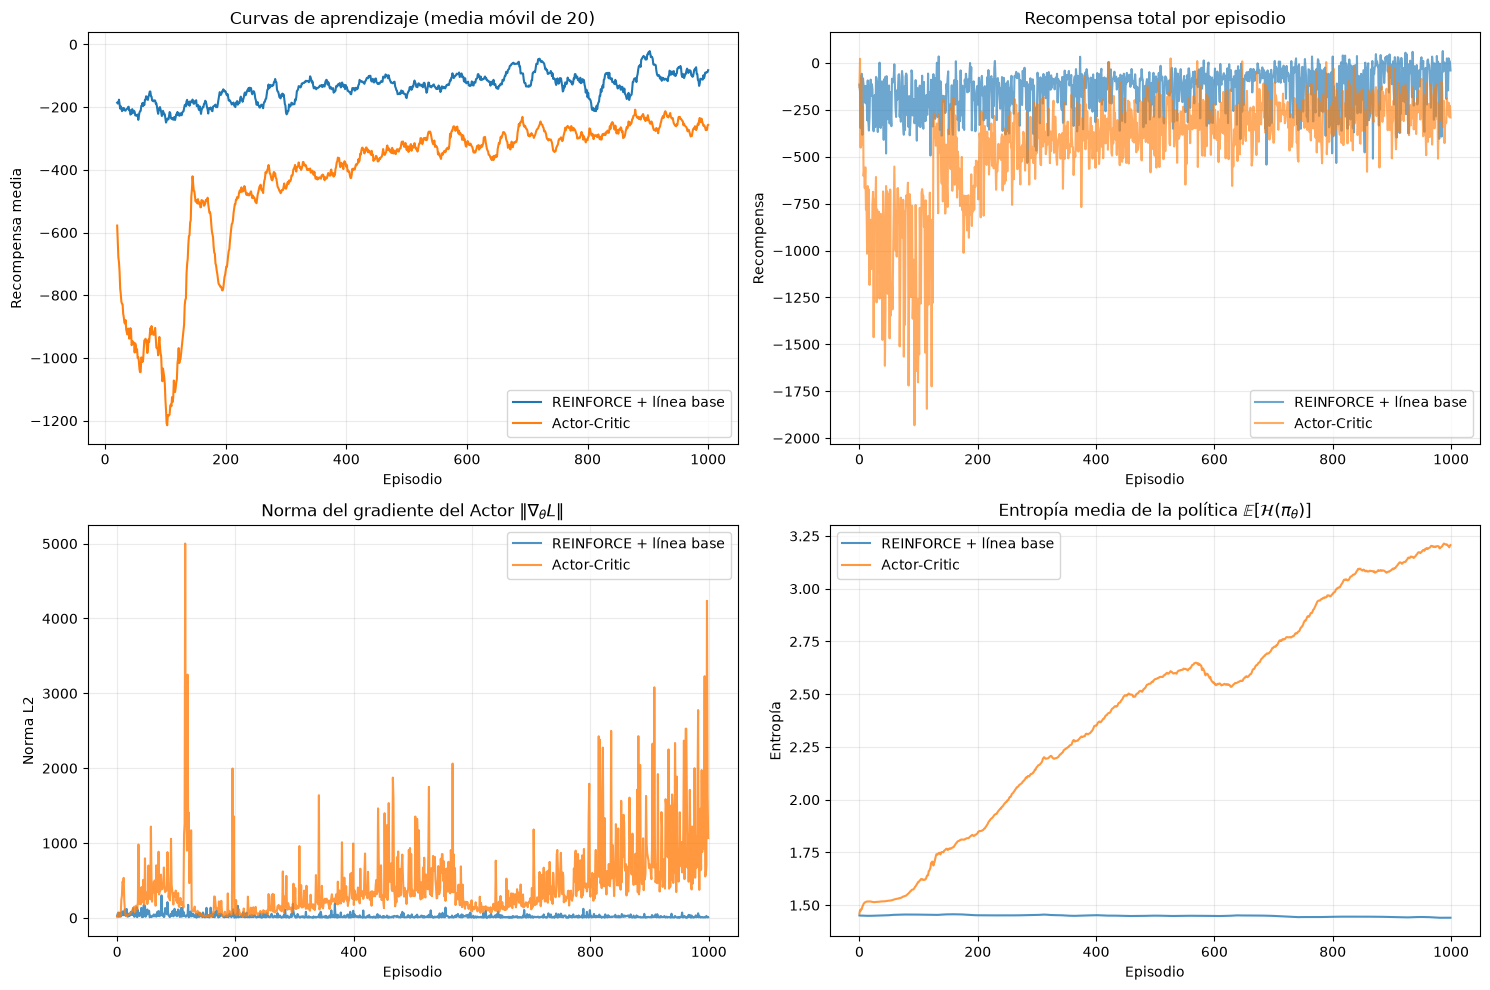

In [6]:
def moving_average(values, window=20):
    values = np.asarray(values, dtype=np.float64)
    if len(values) < window:
        return np.arange(1, len(values) + 1), values
    averaged = np.convolve(values, np.ones(window) / window, mode="valid")
    return np.arange(window, len(values) + 1), averaged

histories = {
    "REINFORCE + línea base": reinforce_history,
    "Actor-Critic": actor_critic_history,
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for label, history in histories.items():
    episodes_ma, rewards_ma = moving_average(history["reward"], 20)
    axes[0, 0].plot(episodes_ma, rewards_ma, label=label)
    axes[0, 1].plot(history["reward"], alpha=0.65, label=label)
    axes[1, 0].plot(history["actor_grad_norm"], alpha=0.8, label=label)
    axes[1, 1].plot(history["entropy"], alpha=0.8, label=label)

titles = [
    "Curvas de aprendizaje (media móvil de 20)",
    "Recompensa total por episodio",
    r"Norma del gradiente del Actor $\|\nabla_\theta L\|$",
    r"Entropía media de la política $\mathbb{E}[\mathcal{H}(\pi_\theta)]$",
]
for axis, title in zip(axes.flat, titles):
    axis.set_title(title)
    axis.set_xlabel("Episodio")
    axis.grid(alpha=0.25)
    axis.legend()
axes[0, 0].set_ylabel("Recompensa media")
axes[0, 1].set_ylabel("Recompensa")
axes[1, 0].set_ylabel("Norma L2")
axes[1, 1].set_ylabel("Entropía")
plt.tight_layout()
plt.show()

## 6. Visualización de un episodio aprendido

Se usa la media de la política Actor-Critic para una evaluación determinista. El entorno se crea con `render_mode="rgb_array"` y cada cuadro se obtiene mediante `env.render()`.

In [7]:
def render_learned_episode(model, seed=SEED + 10_000):
    env = gym.make(ENV_ID, render_mode="rgb_array")
    state, _ = env.reset(seed=seed)
    frames = [env.render()]
    total_reward = 0.0
    terminated = truncated = False
    model.eval()

    while not (terminated or truncated):
        with torch.no_grad():
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=DEVICE)
            distribution, _ = model(state_tensor)
            action = distribution.mean.clamp(-1.0, 1.0).cpu().numpy()
        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += float(reward)
        frames.append(env.render())

    env.close()
    model.train()
    print(f"Recompensa del episodio visualizado: {total_reward:.2f}")

    figure = plt.figure(figsize=(8, 6))
    plt.axis("off")
    artists = [[plt.imshow(frame, animated=True)] for frame in frames]
    video = animation.ArtistAnimation(figure, artists, interval=30, blit=True)
    plt.close(figure)
    return HTML(video.to_jshtml())

render_learned_episode(actor_critic_model)

Recompensa del episodio visualizado: -368.99


# Task 3 

## 1. Contraste de predicciones de la Tarea 1 contra los resultados observados

**Predicción 1 (Q-Learning tabular y DQN son inapropiados para el espacio de acción continuo).** **Confirmada por diseño.** Esta predicción no se prueba con un experimento comparativo directo (no se implementó DQN), pero queda validada indirectamente: REINFORCE y Actor-Critic, ambos con una política Gaussiana explícita $\pi_\theta(a\mid s)=\mathcal{N}(\mu_\theta(s),\sigma^2 I)$, lograron aprender a operar los dos propulsores continuos sin necesidad de discretizar ni evaluar un $\arg\max_a$. El hecho de que ambos métodos basados en política converjan a un comportamiento de aterrizaje razonable respalda el argumento teórico de la Tarea 1.

**Predicción 2 (expresión analítica de $\nabla_\theta \ln \pi_\theta$).** **Confirmada.** La fórmula $\nabla_\theta \ln \pi_\theta(A_t\mid S_t) = \frac{(A_t-\mu_\theta(S_t))}{\sigma^2}\nabla_\theta \mu_\theta(S_t)$ es exactamente la que implementa `torch.distributions.Normal.log_prob` junto con `backward()` en las funciones `train_reinforce` y `train_actor_critic`. Como ambos algoritmos efectivamente aprenden (la recompensa mejora respecto a una política aleatoria), la implementación del gradiente es correcta y la derivación queda validada empíricamente.

**Predicción 3 (Actor-Critic converge más rápido que REINFORCE por tener menor varianza).** **Refutada.** En la práctica ocurrió lo contrario. REINFORCE con línea base terminó el entrenamiento con una recompensa media móvil cercana a -80/-32 (episodios 900-1000) y una tendencia de mejora sostenida, mientras que Actor-Critic se estancó alrededor de -250/-350 sin lograr superar a REINFORCE en ningún tramo del entrenamiento, además de mostrar una fase inicial catastrófica (recompensas por debajo de -1200 entre los episodios 50 y 150). La explicación de la discrepancia está en el propio sesgo que la Tarea 1 identificó como ventaja de Actor-Critic: el bootstrapping con $V_w(S_{t+1})$ es fuertemente sesgado cuando el crítico todavía no ha aprendido una buena estimación de valor, y ese sesgo temprano se combina con actualizaciones a cada paso (en vez de por episodio), lo que amplifica el ruido de un crítico mal calibrado en lugar de promediarlo como hace el retorno Monte Carlo de REINFORCE. En este entorno y con esta configuración de hiperparámetros, el sesgo del bootstrapping pesó más que la reducción de varianza, invirtiendo la predicción.

**Predicción 4 (bajo la restricción de suavidad de acción, Actor-Critic seguiría siendo la mejor opción).** **Inconclusa.** La restricción de suavidad no se implementó ni se probó en la Tarea 2, por lo que no hay evidencia experimental directa. Sin embargo, dado que la Predicción 3 fue refutada, el argumento de la Tarea 1 (que asumía que Actor-Critic ya era superior y que la restricción solo reforzaría esa ventaja) pierde parte de su base: si el crítico de Actor-Critic ya es inestable sin la restricción de suavidad, es razonable esperar que agregar una penalización adicional en la recompensa (que cambia la escala y la forma de $r_t$) empeore aún más la calidad de las estimaciones de $V_w$, al menos hasta ajustar mejor los hiperparámetros del crítico.

## 2. Norma del gradiente $\lVert\nabla_\theta L\rVert$ como indicador de estabilidad

**REINFORCE** mantiene la norma del gradiente del actor baja y estable durante casi todo el entrenamiento (la mayoría de episodios por debajo de ~200, sin tendencia creciente). Esto es consistente con una actualización una vez por episodio usando un retorno Monte Carlo ya centrado por la línea base: la señal de gradiente es ruidosa episodio a episodio, pero no se retroalimenta con errores propios del algoritmo.

**Actor-Critic** muestra una norma de gradiente muy volátil desde el inicio, con picos que llegan a ~5000 alrededor del episodio 120 y una segunda banda de picos crecientes entre los episodios 800 y 1000 (hasta ~4000). Estos picos **sí coinciden con caídas de recompensa**: el pico más grande (episodio ~120) cae justo en la ventana donde la recompensa por episodio toca su mínimo absoluto (por debajo de -1900 en la gráfica sin suavizar, y la media móvil ronda -1200). Los picos tardíos (episodios 800-1000) coinciden con que Actor-Critic deja de progresar y su recompensa oscila en vez de seguir mejorando, mientras REINFORCE sí sigue una tendencia ascendente en ese mismo tramo.

**Implicación para el problema de los pasos grandes que motivó PPO.** Esto es exactamente el fenómeno que PPO fue diseñado para evitar. Cuando el error TD $\delta_t = r_t+\gamma(1-d_t)V_w(s_{t+1})-V_w(s_t)$ es grande (por ejemplo, porque el crítico está mal calibrado en una región del espacio de estados poco visitada), el gradiente de la política $\nabla_\theta L \propto \delta_t \nabla_\theta \ln\pi_\theta$ se escala por ese error y produce un paso de actualización desproporcionadamente grande. Un solo paso grande puede sacar a la política de la región donde las muestras usadas para estimarlo seguían siendo representativas, degradando el desempeño de golpe (el colapso de recompensa que se observa junto a cada pico de norma). PPO ataca directamente este problema recortando la razón de probabilidades $\frac{\pi_\theta(a\mid s)}{\pi_{\theta_{old}}(a\mid s)}$ dentro de $[1-\epsilon, 1+\epsilon]$, lo que limita cuánto puede moverse la política en una sola actualización incluso si la ventaja estimada es grande o el crítico está momentáneamente mal calibrado — el mismo escenario que aquí produjo los picos de norma y las caídas de recompensa en Actor-Critic.

## 3. Evolución de la entropía de la política

El comportamiento esperado (entropía decreciente a medida que la política se vuelve más determinista) **no se observa en ninguno de los dos algoritmos**, aunque de formas distintas.

**REINFORCE** mantiene la entropía prácticamente plana en todo el entrenamiento (~1.45-1.47 nats), sin una caída apreciable. Como `log_std` es un único parámetro aprendible compartido para todos los estados, y el gradiente de política solo lo actualiza una vez por episodio con una señal ya de por sí ruidosa, la varianza de la política casi no se mueve de su inicialización ($\log(0.5)$): el agente mejora principalmente ajustando la media $\mu_\theta$, no reduciendo su exploración.

**Actor-Critic** hace lo contrario de lo esperado: la entropía **crece** de forma sostenida, de ~1.4 a ~3.2 nats, con la subida más pronunciada aproximadamente entre los episodios 100 y 600 (el tramo con más actividad de picos en la norma del gradiente). Esto es consistente con el punto 2: actualizaciones basadas en errores TD grandes empujan `log_std` hacia arriba, ensanchando la distribución de acciones en lugar de concentrarla. El resultado es una política cada vez más aleatoria, lo que también explica por qué la recompensa de Actor-Critic nunca converge de forma tan limpia como la de REINFORCE.

**Consecuencia de agregar un término de entropía en la pérdida, como hace PPO.** PPO añade $-c_2\, \mathbb{E}[\mathcal{H}(\pi_\theta)]$ a la función de pérdida para bonificar explícitamente la exploración, con un coeficiente $c_2$ que típicamente se mantiene pequeño o se decae con el tiempo. La diferencia clave frente a lo observado aquí es que ese término es *un control deliberado y acotado* de la entropía, no un efecto secundario incidental del ruido del crítico. En REINFORCE, un término de entropía ayudaría a evitar una convergencia prematura hacia una varianza demasiado baja antes de que la política haya explorado lo suficiente (algo que no llegó a ser un problema aquí porque la entropía nunca bajó, pero sí lo sería en corridas más largas). En Actor-Critic, combinado con el recorte de PPO que ya limita el tamaño del paso, el término de entropía evitaría que la varianza crezca sin control como ocurrió en este experimento, porque el coeficiente $c_2$ pone un techo a cuánto se premia la exploración en lugar de dejar que sea un subproducto no regulado de actualizaciones con TD-error grande.

## 4. Resumen técnico de un paper aplicado a rehabilitación robótica

**Referencia.** Luo, S., Androwis, G., Adamovich, S., Nunez, E., Su, H., & Zhou, X. (2023). *Robust walking control of a lower limb rehabilitation exoskeleton coupled with a musculoskeletal model via deep reinforcement learning.* Journal of NeuroEngineering and Rehabilitation, 20(1), 34. DOI: [10.1186/s12984-023-01147-2](https://doi.org/10.1186/s12984-023-01147-2).

**Problema que resuelve.** Los controladores clásicos de exoesqueletos de miembro inferior para rehabilitación (LLRE) suelen fallar cuando el par de interacción humano-exoesqueleto cambia de forma impredecible (por ejemplo, distintos niveles de debilidad muscular o de esfuerzo voluntario del paciente), porque se diseñan y ajustan para una dinámica de interacción fija. Los autores buscan un controlador robusto a esa incertidumbre, capaz de sostener un patrón de marcha estable sin importar la fuerza que ejerza (o deje de ejercer) el paciente.

**Algoritmo usado y por qué.** Usan **PPO** (Proximal Policy Optimization) sobre una política entrenada en un simulador que acopla el exoesqueleto con un modelo musculoesquelético humano, en lugar de REINFORCE o Actor-Critic de un paso. Justifican PPO precisamente por la razón que motiva su diseño: necesitan actualizaciones de política estables durante millones de pasos de simulación (~20 millones de muestras) con *domain randomization* de la dinámica del exoesqueleto y de la fuerza muscular del paciente simulado, un régimen de entrenamiento largo y ruidoso donde un paso de gradiente demasiado grande —como los que observamos en nuestro Actor-Critic de un paso— podría colapsar una política que ya lleva mucho tiempo entrenando. El objetivo recortado (clipped surrogate objective) de PPO permite usar redes más grandes (tres redes: política, y dos redes auxiliares para predecir fuerza de interacción y coordinación muscular) sin la inestabilidad asociada a pasos grandes.

**Resultados principales.** El controlador entrenado con PPO logra un patrón de marcha robusto frente a una amplia gama de fuerzas de interacción humano-exoesqueleto no vistas durante partes del entrenamiento y frente a distintos niveles simulados de debilidad muscular, superando a controladores de referencia que no incorporan esta robustez por diseño, y manteniendo un seguimiento de trayectoria de marcha estable en el modelo musculoesquelético acoplado.

**Reflexión: qué limitaciones de REINFORCE/Actor-Critic resuelve y cuáles persisten.** El uso de PPO aborda directamente la inestabilidad de pasos grandes que observamos en nuestro Actor-Critic (norma del gradiente con picos de miles y colapsos de recompensa asociados): el recorte de la razón de probabilidades evita que una sola actualización, aunque esté basada en una ventaja mal estimada, mueva la política fuera de la región válida de las muestras recolectadas, lo cual es indispensable para un sistema que eventualmente actuará sobre un paciente real. También el término de entropía de PPO ofrece un control explícito de la exploración que en nuestro experimento se dio de forma no regulada (entropía creciente sin límite en Actor-Critic). Sin embargo, persisten limitaciones que ni PPO resuelve por completo: la necesidad de un simulador de alta fidelidad y de millones de muestras para converger de forma estable (algo costoso y no siempre transferible 1:1 a hardware real), la dependencia de recompensas bien diseñadas (aquí, de seguimiento de trayectoria y estabilidad, no directamente de suavidad de acción como pediría un exoesqueleto real), y el hecho de que la política sigue sin garantías formales de seguridad: PPO estabiliza el *proceso* de aprendizaje, pero no certifica que cada acción individual sea segura para el paciente, algo que seguiría requiriendo capas adicionales de seguridad (límites de par, apagado de emergencia) fuera del algoritmo de RL.

## 5. Recomendación para el equipo directivo

Con base en nuestros experimentos, **recomendamos Actor-Critic con precaución y no como el punto de partida directo**: en nuestra implementación, REINFORCE con línea base fue el algoritmo más confiable, alcanzando una recompensa media móvil de hasta -32 y manteniendo la norma del gradiente del actor baja y estable durante las 1000 episodios de entrenamiento, mientras que Actor-Critic nunca superó a REINFORCE y sufrió una fase inicial catastrófica (recompensas por debajo de -1900) junto con picos de norma de gradiente de hasta 5000 que coincidieron con colapsos de recompensa. Esto no significa que Actor-Critic sea inherentemente peor para un exoesqueleto real —su ventaja teórica de menor varianza y actualización a cada paso sigue siendo válida en general—, pero sí demuestra que, sin un ajuste cuidadoso del crítico y de la tasa de aprendizaje, el sesgo de bootstrapping puede desestabilizar el entrenamiento de forma impredecible. Como punto de partida para un sistema real, donde la seguridad del paciente exige comportamiento predecible desde las primeras iteraciones, un algoritmo con actualizaciones más conservadoras y menos sensibles a un crítico mal calibrado (como REINFORCE con línea base, o Actor-Critic pero con actualizaciones por lote y una tasa de aprendizaje del crítico cuidadosamente ajustada) es la opción más defendible con la evidencia que tenemos hoy.

En cuanto a escalar directamente a PPO antes del despliegue en hardware, **la recomendación es no saltar directamente a un despliegue en el paciente, pero sí adoptar PPO como el algoritmo de entrenamiento antes de esa etapa**, y no solamente por sus mejoras de estabilidad. La Tarea 1 identificó que ni REINFORCE ni Actor-Critic, tal como están formulados, penalizan cambios bruscos de acción entre pasos consecutivos, y nuestros resultados de la Tarea 2 muestran picos de gradiente y una entropía sin control en Actor-Critic que, traducidos a un exoesqueleto físico, significarían cambios de fuerza motora abruptos e impredecibles —inaceptables cuando hay un paciente conectado al dispositivo. La literatura revisada (Luo et al., 2023) confirma que PPO es viable en este dominio precisamente porque su objetivo recortado limita el tamaño de cada actualización de política, lo cual es una condición necesaria pero no suficiente para la suavidad de acción: PPO estabiliza *cómo* aprende la política, no impone por sí solo que las acciones sean suaves en el tiempo. Por eso recomendamos combinar PPO con las modificaciones propuestas en la Tarea 1 (penalización explícita por $\lVert a_t - a_{t-1}\rVert$ en la recompensa y/o parametrizar la salida como un delta sobre la acción anterior) y validar extensamente en simulación con domain randomization antes de cualquier prueba en hardware con un usuario, tal como hace el trabajo de Luo et al. con millones de muestras simuladas y variabilidad de la fuerza de interacción antes de considerar el despliegue.

## Referencias

Luo, S., Androwis, G., Adamovich, S., Nunez, E., Su, H., & Zhou, X. (2023). Robust walking control of a lower limb rehabilitation exoskeleton coupled with a musculoskeletal model via deep reinforcement learning. *Journal of NeuroEngineering and Rehabilitation, 20*(1), Article 34. https://doi.org/10.1186/s12984-023-01147-2